In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df = pd.read_csv("../data/sample_car_contracts.csv")

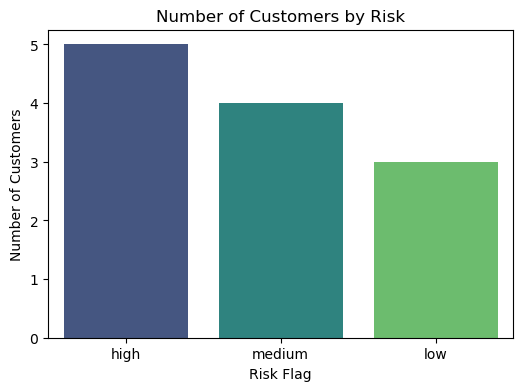

In [16]:
risk_counts = df['risk_flag'].value_counts()

plt.figure(figsize=(6,4))
sns.barplot(
    x=risk_counts.index,
    y=risk_counts.values,
    hue=risk_counts.index,      
    palette='viridis',          
    legend=False
)
plt.title('Number of Customers by Risk')
plt.xlabel('Risk Flag')
plt.ylabel('Number of Customers')
plt.show()

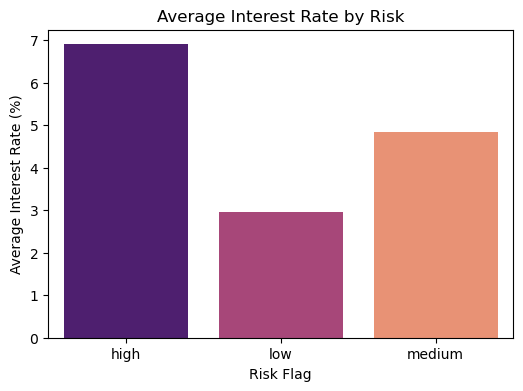

In [17]:
avg_interest = df.groupby('risk_flag')['interest_rate'].mean().reset_index()

plt.figure(figsize=(6,4))
sns.barplot(x='risk_flag', y='interest_rate', data=avg_interest,hue='risk_flag', palette='magma',legend=False )
plt.title('Average Interest Rate by Risk')
plt.xlabel('Risk Flag')
plt.ylabel('Average Interest Rate (%)')
plt.show()

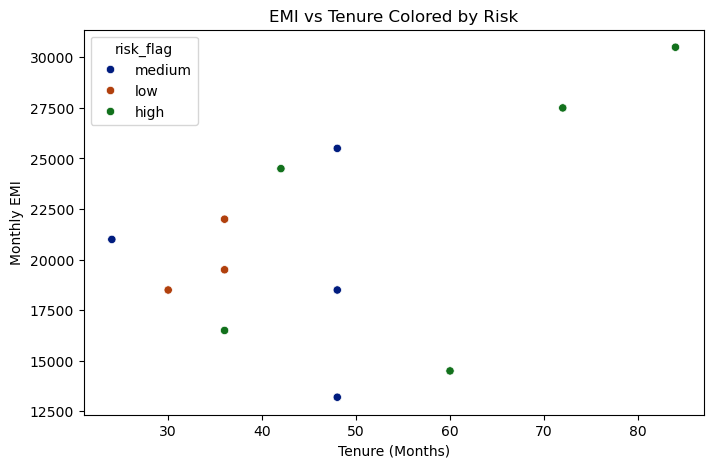

In [18]:
plt.figure(figsize=(8,5))
sns.scatterplot(x='tenure_months', y='monthly_emi', hue='risk_flag', data=df, palette='dark')
plt.title('EMI vs Tenure Colored by Risk')
plt.xlabel('Tenure (Months)')
plt.ylabel('Monthly EMI')
plt.show()

In [10]:
df["tenure_years"] = df["tenure_months"] / 12
df["total_amount"] = df["monthly_emi"] * df["tenure_months"]
df[["monthly_emi", "tenure_years","total_amount"]]


,monthly_emi,tenure_years,total_amount
0,18500,4.0,888000
1,22000,3.0,792000
2,14500,5.0,870000
3,21000,2.0,504000
4,27500,6.0,1980000
5,16500,3.0,594000
6,19500,3.0,702000
7,25500,4.0,1224000
8,30500,7.0,2562000
9,18500,2.5,555000


In [6]:
avg_total = df.groupby("risk_flag")["total_amount"].mean()
avg_total
avg_emi = df.groupby("risk_flag")["monthly_emi"].mean()
avg_emi
avg_tenure=df.groupby("risk_flag")["tenure_years"].mean()
avg_tenure
pd.crosstab(df["risk_flag"], df["recommended_action"])

recommended_action,"Explain condition for refund, low risk",Explain floating rate risk and suggest asking for external benchmark or cap,Flag as risky and suggest negotiating lower termination fee,Flag as unfair tying and suggest independent insurance quote,Flag clause and suggest user request cap on late fee,Highlight cost and suggest user negotiate lower fee,Highlight prepayment penalty to user and suggest negotiation for lower fee,"Mark as positive clause, no action required","No action, just explain maintenance responsibility to user",Strongly warn user and recommend clarification / negotiation,Warn user about battery risk and suggest extended warranty discussion,Warn user about extra mileage charges and recommend realistic mileage estimate
risk_flag,,,,,,,,,,,,
high,0,1,1,1,1,0,0,0,0,1,0,0
low,1,0,0,0,0,0,0,1,1,0,0,0
medium,0,0,0,0,0,1,1,0,0,0,1,1
